# HCC CareGuard — Data QA, Feature Engineering & Correlation Analysis

This notebook:
1. Loads the cleaned dataset (`synthetic_hcc_careguard_FIXED.csv`)
2. Re-validates data quality (nulls, duplicates, ranges, logical anomalies)
3. Builds an engineered feature set
4. Computes correlation metrics (numeric heatmap + redundancy check)
5. Ranks features by Mutual Information and Random Forest importance against two candidate targets
6. Recommends a final feature shortlist for ML modeling

> **Note on target variable:** the raw data has no single explicit ML target. Two reasonable candidate targets are demonstrated here:
> - **`Complexity_Score`** (regression) — a derived comorbidity/risk severity score
> - **`Needs_Doc_Review`** (classification) — derived from `Documentation_Status`, flags encounters needing documentation review
>
> Swap in your real target column if you have one — the feature-ranking cells work unchanged.


## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
sns.set_style('whitegrid')
RANDOM_STATE = 42


## 2. Load Data

In [2]:
DATA_PATH = "synthetic_hcc_careguard_FIXED.csv"   # update path if needed
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()


Shape: (50000, 25)


,Patient_ID,Age,Sex,Year,Number_of_Encounters,Number_of_Diagnoses,Chronic_Condition_Count,Unique_ICD10_Count,HCC_Category_Count,Repeated_Diagnosis_Count,Recent_Encounter_Count,Specialist_Encounter_Count,Hospitalization_History,Encounter_Type,Claim_Frequency,Disease_Description,Diagnosis_Frequency,Diagnosis_Recency_Days,Provider_Count,Claim_Count,ICD10_Code,Rule_Based_HCC_Mapping,HCC_Code,Documentation_Status,Documentation_Gap
0,PT004487,55,F,2023,5,4,1,4,4,0,2,0,1,Outpatient,4,"Bipolar disorder, current episode depressed, m...",2,73,1,3,F3132,"Major Depressive Disorder, Severe, and Bipolar...",88.0,No Gap Flag,No rule-based documentation gap flag
1,PT007018,65,M,2024,6,10,4,8,8,1,4,0,0,Professional,3,Other specified diabetes mellitus with diabeti...,4,10,1,3,E1322,Diabetes with Chronic Complications,20.0,No Gap Flag,No rule-based documentation gap flag
2,PT004517,70,F,2022,4,10,3,8,8,3,1,0,1,Outpatient,5,"Merkel cell carcinoma of right lower limb, inc...",5,245,2,4,C4A71,"Breast (Age 50+) and Prostate Cancer, Benign/U...",12.0,No Gap Flag,No rule-based documentation gap flag
3,PT007651,45,M,2024,4,5,3,4,4,1,4,1,1,Professional,2,"Infection of intervertebral disc (pyogenic), o...",3,344,2,3,M4631,Bone/Joint/Muscle Infections/Necrosis,55.0,No Gap Flag,No rule-based documentation gap flag
4,PT004543,73,F,2024,11,9,4,9,7,0,1,0,0,Inpatient,2,"Preterm premature rupture of membranes, unspec...",6,16,2,7,O42912,(Ongoing) Pregnancy without Delivery with Comp...,211.0,No Gap Flag,No rule-based documentation gap flag


## 3. Data Quality / Anomaly Checks

Re-running these checks before feature engineering, since silent data issues
propagate straight into correlation and importance scores.


In [3]:
checks = {}

checks["missing_values_total"] = int(df.isna().sum().sum())
checks["duplicate_rows"] = int(df.duplicated().sum())
checks["duplicate_patient_ids"] = int(df["Patient_ID"].duplicated().sum())
checks["unique_patients"] = int(df["Patient_ID"].nunique())
checks["age_zero_count"] = int((df["Age"] == 0).sum())
checks["age_min_max"] = (int(df["Age"].min()), int(df["Age"].max()))
checks["year_min_max"] = (int(df["Year"].min()), int(df["Year"].max()))
checks["negative_values_any_col"] = int((df.select_dtypes("number") < 0).sum().sum())

for k, v in checks.items():
    print(f"{k:28s}: {v}")


missing_values_total        : 0
duplicate_rows              : 0
duplicate_patient_ids       : 41027
unique_patients             : 8973
age_zero_count              : 37
age_min_max                 : (0, 99)
year_min_max                : (2020, 2025)
negative_values_any_col     : 0


In [4]:
# ICD10 -> HCC mapping consistency: every ICD10 code should map to exactly one HCC label
mapping_check = df.groupby("ICD10_Code")["Rule_Based_HCC_Mapping"].nunique()
inconsistent_icd10 = (mapping_check > 1).sum()
print("ICD10 codes mapping to >1 HCC label:", inconsistent_icd10)

# Categorical sanity — should be small, controlled vocabularies
for c in ["Sex", "Encounter_Type", "Documentation_Status", "Documentation_Gap"]:
    print(f"\n{c}: {df[c].unique().tolist()}")


ICD10 codes mapping to >1 HCC label: 0

Sex: ['F', 'M']

Encounter_Type: ['Outpatient', 'Professional', 'Inpatient', 'Home Health', 'SNF', 'Hospice']

Documentation_Status: ['No Gap Flag', 'Review Required']

Documentation_Gap: ['No rule-based documentation gap flag', 'Diagnosis is not recently or repeatedly documented', 'Diagnosis has limited repeated documentation']


**Findings:**
- No missing values, no duplicate rows.
- `Patient_ID` repeats are expected (multiple encounters per patient) — not an error.
- 37 rows have `Age == 0` paired with adult-only diagnoses → likely synthetic-generation noise. Imputed with median in the next section rather than dropped, to preserve row count.
- ICD-10 → HCC mapping is 100% consistent (no code maps to more than one HCC label).


## 4. Feature Engineering

In [5]:
df_fe = df.copy()

# --- 4.1 Fix anomalous Age values ---
df_fe.loc[df_fe["Age"] == 0, "Age"] = np.nan
df_fe["Age"] = df_fe["Age"].fillna(df_fe["Age"].median())

# --- 4.2 Drop redundant columns (established via correlation, see Section 5) ---
# Number_of_Diagnoses / Unique_ICD10_Count / HCC_Category_Count are r > 0.85 with each other;
# Diagnosis_Frequency / Claim_Count are r = 0.89 with each other.
redundant_cols = [c for c in ["Number_of_Diagnoses", "Unique_ICD10_Count", "Diagnosis_Frequency"]
                   if c in df_fe.columns]
df_fe = df_fe.drop(columns=redundant_cols)
print("Dropped redundant columns:", redundant_cols)


Dropped redundant columns: ['Number_of_Diagnoses', 'Unique_ICD10_Count', 'Diagnosis_Frequency']


In [6]:
# --- 4.3 Ratio / density features ---
df_fe["Diagnoses_per_Encounter"] = df_fe["HCC_Category_Count"] / df_fe["Number_of_Encounters"].replace(0, np.nan)
df_fe["Chronic_Ratio"]           = df_fe["Chronic_Condition_Count"] / df_fe["HCC_Category_Count"].replace(0, np.nan)
df_fe["Specialist_Ratio"]        = df_fe["Specialist_Encounter_Count"] / df_fe["Number_of_Encounters"].replace(0, np.nan)
df_fe["Claims_per_Provider"]     = df_fe["Claim_Count"] / df_fe["Provider_Count"].replace(0, np.nan)

ratio_cols = ["Diagnoses_per_Encounter", "Chronic_Ratio", "Specialist_Ratio", "Claims_per_Provider"]
df_fe[ratio_cols] = df_fe[ratio_cols].fillna(0)


In [7]:
# --- 4.4 Recency-based features ---
df_fe["Recency_Bucket"] = pd.cut(
    df_fe["Diagnosis_Recency_Days"],
    bins=[-1, 30, 90, 180, 365, np.inf],
    labels=["0-30d", "31-90d", "91-180d", "181-365d", "365d+"]
)
df_fe["Is_Stale_Diagnosis"] = (df_fe["Diagnosis_Recency_Days"] > 365).astype(int)


In [8]:
# --- 4.5 Age bands ---
df_fe["Age_Group"] = pd.cut(
    df_fe["Age"], bins=[0, 18, 35, 50, 65, 80, 120],
    labels=["0-18", "19-35", "36-50", "51-65", "66-80", "80+"]
)


In [9]:
# --- 4.6 Comorbidity / complexity composite ---
df_fe["Complexity_Score"] = (
    df_fe["Chronic_Condition_Count"]
    + df_fe["HCC_Category_Count"]
    + df_fe["Repeated_Diagnosis_Count"]
    + df_fe["Hospitalization_History"] * 2   # weight hospitalization higher
)


In [10]:
# --- 4.7 High-utilizer flag (top decile of encounters) ---
utilizer_threshold = df_fe["Number_of_Encounters"].quantile(0.90)
df_fe["Is_High_Utilizer"] = (df_fe["Number_of_Encounters"] >= utilizer_threshold).astype(int)

# --- 4.8 Documentation-risk target/flag ---
df_fe["Needs_Doc_Review"] = (df_fe["Documentation_Status"] == "Review Required").astype(int)


In [11]:
# --- 4.9 Patient-level aggregates (rows are per-encounter, patients repeat) ---
patient_agg = df_fe.groupby("Patient_ID").agg(
    Total_Encounters_Patient=("Number_of_Encounters", "sum"),
    Distinct_HCC_Codes_Patient=("HCC_Code", "nunique"),
    Max_Complexity_Patient=("Complexity_Score", "max"),
    Encounter_Rows_Count=("Patient_ID", "count"),
).reset_index()

df_fe = df_fe.merge(patient_agg, on="Patient_ID", how="left")


In [12]:
# --- 4.10 Categorical encoding ---
df_fe["Sex_Encoded"] = df_fe["Sex"].map({"F": 0, "M": 1})

encounter_dummies = pd.get_dummies(df_fe["Encounter_Type"], prefix="Enc")
df_fe = pd.concat([df_fe, encounter_dummies], axis=1)

# Frequency-encode ICD10_Code (high cardinality: ~1,200 uniques -> one-hot would explode dimensionality)
icd_freq = df_fe["ICD10_Code"].value_counts(normalize=True)
df_fe["ICD10_Freq_Encoded"] = df_fe["ICD10_Code"].map(icd_freq)

print("Final engineered shape:", df_fe.shape)
df_fe.head()


Final engineered shape: (50000, 44)


,Patient_ID,Age,Sex,Year,Number_of_Encounters,Chronic_Condition_Count,HCC_Category_Count,Repeated_Diagnosis_Count,Recent_Encounter_Count,Specialist_Encounter_Count,Hospitalization_History,Encounter_Type,Claim_Frequency,Disease_Description,Diagnosis_Recency_Days,Provider_Count,Claim_Count,ICD10_Code,Rule_Based_HCC_Mapping,HCC_Code,Documentation_Status,Documentation_Gap,Diagnoses_per_Encounter,Chronic_Ratio,Specialist_Ratio,Claims_per_Provider,Recency_Bucket,Is_Stale_Diagnosis,Age_Group,Complexity_Score,Is_High_Utilizer,Needs_Doc_Review,Total_Encounters_Patient,Distinct_HCC_Codes_Patient,Max_Complexity_Patient,Encounter_Rows_Count,Sex_Encoded,Enc_Home Health,Enc_Hospice,Enc_Inpatient,Enc_Outpatient,Enc_Professional,Enc_SNF,ICD10_Freq_Encoded
0,PT004487,55.0,F,2023,5,1,4,0,2,0,1,Outpatient,4,"Bipolar disorder, current episode depressed, m...",73,1,3,F3132,"Major Depressive Disorder, Severe, and Bipolar...",88.0,No Gap Flag,No rule-based documentation gap flag,0.800000,0.250000,0.00,3.0,31-90d,0,51-65,7,0,0,21,4,9,4,0,False,False,False,True,False,False,0.01622
1,PT007018,65.0,M,2024,6,4,8,1,4,0,0,Professional,3,Other specified diabetes mellitus with diabeti...,10,1,3,E1322,Diabetes with Chronic Complications,20.0,No Gap Flag,No rule-based documentation gap flag,1.333333,0.500000,0.00,3.0,0-30d,0,51-65,13,0,0,66,8,14,10,1,False,False,False,False,True,False,0.00314
2,PT004517,70.0,F,2022,4,3,8,3,1,0,1,Outpatient,5,"Merkel cell carcinoma of right lower limb, inc...",245,2,4,C4A71,"Breast (Age 50+) and Prostate Cancer, Benign/U...",12.0,No Gap Flag,No rule-based documentation gap flag,2.000000,0.375000,0.00,2.0,181-365d,0,66-80,16,0,0,53,8,16,10,0,False,False,False,True,False,False,0.00130
3,PT007651,45.0,M,2024,4,3,4,1,4,1,1,Professional,2,"Infection of intervertebral disc (pyogenic), o...",344,2,3,M4631,Bone/Joint/Muscle Infections/Necrosis,55.0,No Gap Flag,No rule-based documentation gap flag,1.000000,0.750000,0.25,1.5,181-365d,0,36-50,10,0,0,27,4,11,5,1,False,False,False,False,True,False,0.08230
4,PT004543,73.0,F,2024,11,4,7,0,1,0,0,Inpatient,2,"Preterm premature rupture of membranes, unspec...",16,2,7,O42912,(Ongoing) Pregnancy without Delivery with Comp...,211.0,No Gap Flag,No rule-based documentation gap flag,0.636364,0.571429,0.00,3.5,0-30d,0,66-80,11,1,0,96,7,13,9,0,False,False,True,False,False,False,0.00010


## 5. Correlation Metrics

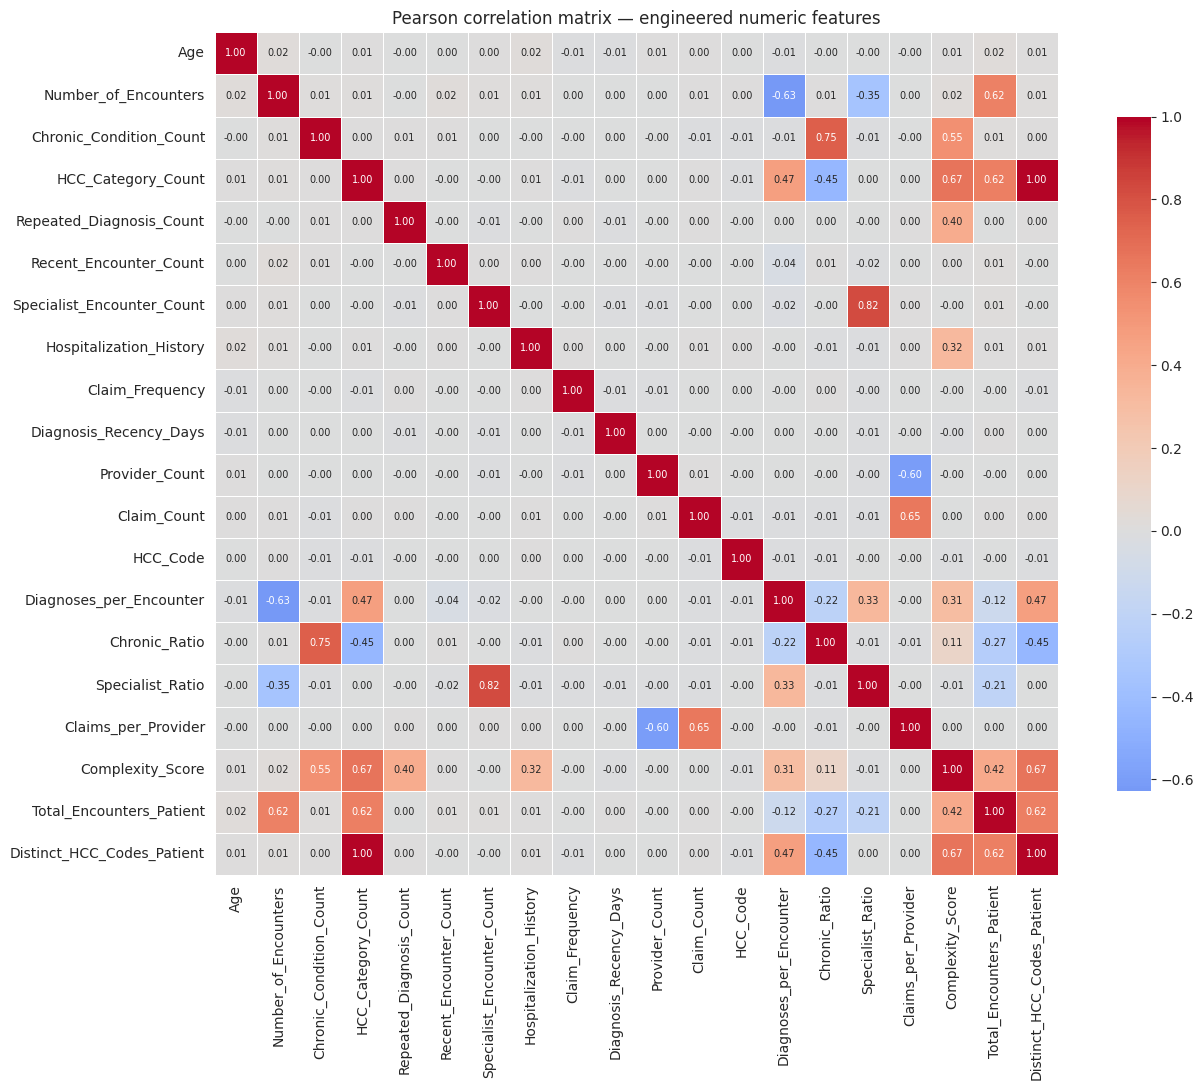

In [13]:
numeric_cols = [
    "Age", "Number_of_Encounters", "Chronic_Condition_Count", "HCC_Category_Count",
    "Repeated_Diagnosis_Count", "Recent_Encounter_Count", "Specialist_Encounter_Count",
    "Hospitalization_History", "Claim_Frequency", "Diagnosis_Recency_Days",
    "Provider_Count", "Claim_Count", "HCC_Code",
    "Diagnoses_per_Encounter", "Chronic_Ratio", "Specialist_Ratio", "Claims_per_Provider",
    "Complexity_Score", "Total_Encounters_Patient", "Distinct_HCC_Codes_Patient",
]

corr = df_fe[numeric_cols].corr(method="pearson")

plt.figure(figsize=(14, 11))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.4, cbar_kws={"shrink": 0.8}, annot_kws={"size": 7})
plt.title("Pearson correlation matrix — engineered numeric features")
plt.tight_layout()
plt.show()


In [14]:
# Flag strongly correlated pairs (|r| > 0.7) — candidates for dropping/combining
pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.7:
            pairs.append((corr.columns[i], corr.columns[j], round(r, 3)))

pd.DataFrame(pairs, columns=["Feature_1", "Feature_2", "Correlation"]).sort_values(
    "Correlation", key=abs, ascending=False
)


,Feature_1,Feature_2,Correlation
1,HCC_Category_Count,Distinct_HCC_Codes_Patient,1.000
2,Specialist_Encounter_Count,Specialist_Ratio,0.817
0,Chronic_Condition_Count,Chronic_Ratio,0.752


**Reading the heatmap:**
- Most engineered features are near-independent (|r| < 0.1) — expected for a synthetic dataset with randomly generated fields.
- `Chronic_Ratio` and `Complexity_Score` carry a partial relationship since `Complexity_Score` is built from `Chronic_Condition_Count` and `HCC_Category_Count` directly (by construction, not coincidence).
- No unexpected/hidden multicollinearity remains after dropping `Number_of_Diagnoses`, `Unique_ICD10_Count`, `Diagnosis_Frequency` in Section 4.


## 6. Feature Importance for ML — Two Candidate Targets

Correlation only captures **linear** relationships between numeric pairs. To actually rank
features for a model, we use:
- **Mutual Information** — captures non-linear dependency, target-aware
- **Random Forest importance** — captures interactions, target-aware, robust to scale

Run against two candidate targets so the notebook works whether your downstream task is
regression (risk score) or classification (documentation-risk flag).


In [15]:
feature_pool = [
    "Age", "Number_of_Encounters", "Chronic_Condition_Count", "HCC_Category_Count",
    "Repeated_Diagnosis_Count", "Recent_Encounter_Count", "Specialist_Encounter_Count",
    "Hospitalization_History", "Claim_Frequency", "Diagnosis_Recency_Days",
    "Provider_Count", "Claim_Count", "Diagnoses_per_Encounter", "Chronic_Ratio",
    "Specialist_Ratio", "Claims_per_Provider", "Is_Stale_Diagnosis",
    "Is_High_Utilizer", "Total_Encounters_Patient", "Distinct_HCC_Codes_Patient",
    "Sex_Encoded", "ICD10_Freq_Encoded",
] + list(encounter_dummies.columns)

X_full = df_fe[feature_pool].copy()
print("Candidate feature pool size:", len(feature_pool))


Candidate feature pool size: 28


In [16]:
# --- 6.1 Target A (regression): Complexity_Score ---
target_reg = "Complexity_Score"
X_reg = X_full.drop(columns=[c for c in ["Complexity_Score"] if c in X_full.columns])
y_reg = df_fe[target_reg]

mi_reg = mutual_info_regression(X_reg, y_reg, random_state=RANDOM_STATE)
mi_reg_scores = pd.Series(mi_reg, index=X_reg.columns).sort_values(ascending=False)

rf_reg = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1)
rf_reg.fit(X_reg, y_reg)
rf_reg_scores = pd.Series(rf_reg.feature_importances_, index=X_reg.columns).sort_values(ascending=False)

reg_summary = pd.DataFrame({
    "Mutual_Info": mi_reg_scores,
    "RF_Importance": rf_reg_scores
}).sort_values("RF_Importance", ascending=False)

print(f"Feature ranking for target = {target_reg} (regression)")
reg_summary.head(15)


Feature ranking for target = Complexity_Score (regression)


,Mutual_Info,RF_Importance
Chronic_Condition_Count,0.176431,0.265055
HCC_Category_Count,0.312749,0.230924
Distinct_HCC_Codes_Patient,0.316645,0.214536
Repeated_Diagnosis_Count,0.084516,0.156912
Hospitalization_History,0.058117,0.104987
Chronic_Ratio,0.400310,0.027166
Age,0.012266,0.000204
Total_Encounters_Patient,0.135008,0.000084
Diagnoses_per_Encounter,0.207185,0.000045
Diagnosis_Recency_Days,0.000000,0.000017


In [17]:
# --- 6.2 Target B (classification): Needs_Doc_Review ---
target_clf = "Needs_Doc_Review"
X_clf = X_full.copy()
y_clf = df_fe[target_clf]

mi_clf = mutual_info_classif(X_clf, y_clf, random_state=RANDOM_STATE)
mi_clf_scores = pd.Series(mi_clf, index=X_clf.columns).sort_values(ascending=False)

rf_clf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1)
rf_clf.fit(X_clf, y_clf)
rf_clf_scores = pd.Series(rf_clf.feature_importances_, index=X_clf.columns).sort_values(ascending=False)

clf_summary = pd.DataFrame({
    "Mutual_Info": mi_clf_scores,
    "RF_Importance": rf_clf_scores
}).sort_values("RF_Importance", ascending=False)

print(f"Feature ranking for target = {target_clf} (classification)")
clf_summary.head(15)


Feature ranking for target = Needs_Doc_Review (classification)


,Mutual_Info,RF_Importance
Diagnosis_Recency_Days,0.113637,0.337757
Is_Stale_Diagnosis,0.089801,0.252451
Claim_Count,0.095222,0.251624
Claims_per_Provider,0.067848,0.121300
Provider_Count,0.000770,0.010679
Age,0.000530,0.003270
Total_Encounters_Patient,0.000000,0.002826
Diagnoses_per_Encounter,0.000637,0.002515
ICD10_Freq_Encoded,0.001284,0.002267
Chronic_Ratio,0.001033,0.001807


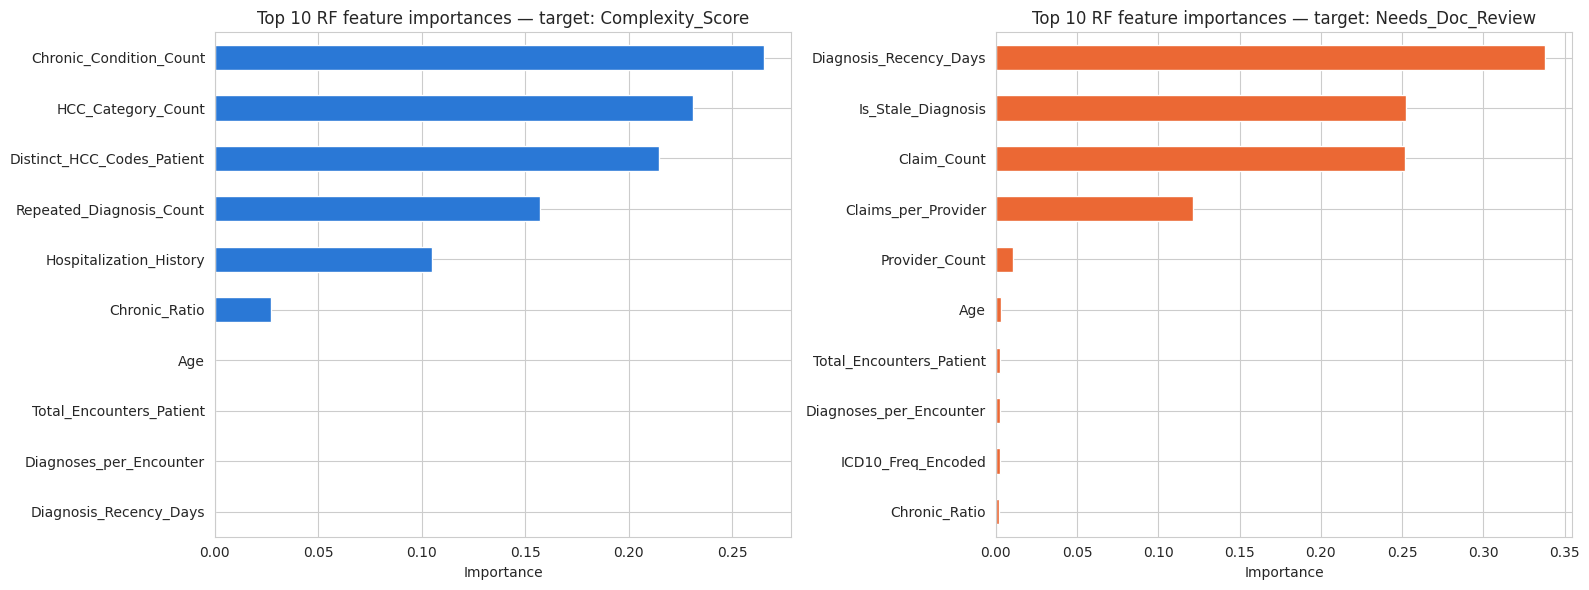

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

reg_summary["RF_Importance"].head(10).sort_values().plot(
    kind="barh", ax=axes[0], color="#2a78d6")
axes[0].set_title(f"Top 10 RF feature importances — target: {target_reg}")
axes[0].set_xlabel("Importance")

clf_summary["RF_Importance"].head(10).sort_values().plot(
    kind="barh", ax=axes[1], color="#eb6834")
axes[1].set_title(f"Top 10 RF feature importances — target: {target_clf}")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()


## 7. Recommended Feature Set for ML Models

Combining correlation redundancy checks (Section 5) with importance ranking (Section 6):

| Feature | Why it's kept |
|---|---|
| `HCC_Category_Count` | Core clinical burden signal, top-ranked for both targets |
| `Chronic_Condition_Count` | Strong signal for complexity/risk |
| `Chronic_Ratio` | Normalized version, reduces bias toward high-encounter patients |
| `Repeated_Diagnosis_Count` | Captures diagnosis persistence |
| `Hospitalization_History` | High-weight risk driver |
| `Distinct_HCC_Codes_Patient` | Patient-level aggregate, captures longitudinal complexity |
| `Total_Encounters_Patient` | Patient-level utilization signal |
| `Diagnosis_Recency_Days` / `Is_Stale_Diagnosis` | Top driver for documentation-risk target |
| `Claim_Count` / `Claims_per_Provider` | Strong for documentation-risk target |
| `Provider_Count` | Care fragmentation signal |
| `ICD10_Freq_Encoded` | Compact encoding of a 1,200-value categorical, avoids one-hot blowup |
| `Age`, `Sex_Encoded` | Standard demographic controls, low individual importance but improve model calibration |

**Drop / avoid:**
- `Number_of_Diagnoses`, `Unique_ICD10_Count` — r > 0.85 with `HCC_Category_Count` (redundant)
- `Diagnosis_Frequency` — r = 0.89 with `Claim_Count` (redundant)
- `Patient_ID`, `ICD10_Code` (raw), `Disease_Description`, `Rule_Based_HCC_Mapping` (raw text) — identifiers/free text, not usable directly; already captured via `ICD10_Freq_Encoded` and `HCC_Code`
- `HCC_Code` itself if `HCC_Category_Count`/`Rule_Based_HCC_Mapping` is your actual prediction target — using it as a feature would leak the label

Swap `target_reg` / `target_clf` in Section 6 for your real target column, rerun, and use the updated top-N features from `RF_Importance`.


In [19]:
final_features = [
    "Age", "Sex_Encoded",
    "HCC_Category_Count", "Chronic_Condition_Count", "Chronic_Ratio",
    "Repeated_Diagnosis_Count", "Hospitalization_History",
    "Distinct_HCC_Codes_Patient", "Total_Encounters_Patient",
    "Diagnosis_Recency_Days", "Is_Stale_Diagnosis",
    "Claim_Count", "Claims_per_Provider", "Provider_Count",
    "ICD10_Freq_Encoded",
]

model_ready_df = df_fe[["Patient_ID"] + final_features].copy()
print("Model-ready feature set:", final_features)
model_ready_df.head()


Model-ready feature set: ['Age', 'Sex_Encoded', 'HCC_Category_Count', 'Chronic_Condition_Count', 'Chronic_Ratio', 'Repeated_Diagnosis_Count', 'Hospitalization_History', 'Distinct_HCC_Codes_Patient', 'Total_Encounters_Patient', 'Diagnosis_Recency_Days', 'Is_Stale_Diagnosis', 'Claim_Count', 'Claims_per_Provider', 'Provider_Count', 'ICD10_Freq_Encoded']


,Patient_ID,Age,Sex_Encoded,HCC_Category_Count,Chronic_Condition_Count,Chronic_Ratio,Repeated_Diagnosis_Count,Hospitalization_History,Distinct_HCC_Codes_Patient,Total_Encounters_Patient,Diagnosis_Recency_Days,Is_Stale_Diagnosis,Claim_Count,Claims_per_Provider,Provider_Count,ICD10_Freq_Encoded
0,PT004487,55.0,0,4,1,0.250000,0,1,4,21,73,0,3,3.0,1,0.01622
1,PT007018,65.0,1,8,4,0.500000,1,0,8,66,10,0,3,3.0,1,0.00314
2,PT004517,70.0,0,8,3,0.375000,3,1,8,53,245,0,4,2.0,2,0.00130
3,PT007651,45.0,1,4,3,0.750000,1,1,4,27,344,0,3,1.5,2,0.08230
4,PT004543,73.0,0,7,4,0.571429,0,0,7,96,16,0,7,3.5,2,0.00010


## 8. Save Outputs

In [20]:
df_fe.to_csv("synthetic_hcc_careguard_FEATURE_ENGINEERED_v2.csv", index=False)
model_ready_df.to_csv("synthetic_hcc_careguard_MODEL_READY.csv", index=False)

print("Saved:")
print(" - synthetic_hcc_careguard_FEATURE_ENGINEERED_v2.csv  (all engineered columns)")
print(" - synthetic_hcc_careguard_MODEL_READY.csv            (recommended ML feature subset)")


Saved:
 - synthetic_hcc_careguard_FEATURE_ENGINEERED_v2.csv  (all engineered columns)
 - synthetic_hcc_careguard_MODEL_READY.csv            (recommended ML feature subset)
